# Sagan HFT Engine: NIFTY50 Benchmark

This notebook demonstrates the capabilities of the **Sagan Trade** HFT engine, benchmarking its PyTorch Mixture-of-Experts + Symbolic model against a standard Machine Learning baseline (Random Forest) on simulated high-frequency order book data for the **NIFTY50** index.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from simulator import HawkesLOBSimulator
from backtester import HighFrequencyBacktester
import torch

# 1. Simulate NIFTY50 Ticks
print("Simulating NIFTY50 Ticks with Hawkes & Bates Jump-Diffusion...")
sim = HawkesLOBSimulator()
df = sim.simulate_ticks("NIFTY50", num_ticks=5000)

print(df.head())


Simulating NIFTY50 Ticks with Hawkes & Bates Jump-Diffusion...


   timestamp  mid_price  bid_price  ask_price  bid_size  ask_size  \
0   0.586578  24001.400   24001.35   24001.45     74905     37547   
1   0.612577  24001.500   24001.45   24001.55     34549     57725   
2   1.319489  24001.825   24001.80   24001.85     21246     64376   
3   1.597905  24001.900   24001.85   24001.95     73039     38480   
4   3.038826  24000.350   24000.30   24000.40     58426     45786   

   hawkes_intensity  trade_occurred  spread      ofi   micro_price  \
0               0.8             0.0    0.10      0.0  24001.416611   
1               0.8             0.0    0.10  34549.0  24001.487442   
2               0.8             0.0    0.05  21246.0  24001.812407   
3               0.8             0.0    0.10  73039.0  24001.915495   
4               0.8             0.0    0.10 -45786.0  24000.356065   

   depth_imbalance  rolling_vol  
0         0.332213     0.000053  
1        -0.251165     0.000053  
2        -0.503726     0.000053  
3         0.309893     0.000

In [2]:
# 2. Feature Engineering & Target Generation
# We want to predict the spread 'latency_ticks' in the future to feed into the queue backtester.
latency_ticks = 2
df['target_spread'] = (df['ask_price'] - df['bid_price']).shift(-latency_ticks)
df.dropna(inplace=True)

# Standard features available from the simulator
features = ['ofi', 'depth_imbalance', 'rolling_vol', 'hawkes_intensity', 'sentiment']
for f in features:
    if f not in df.columns:
        df[f] = 0.0

X = df[features].values
y = df['target_spread'].values

# Train/Test Split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
df_test = df.iloc[split_idx:].reset_index(drop=True)


In [3]:
# 3. Baseline ML Model: Random Forest
print("Training Random Forest Baseline...")
rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

baseline_preds = rf.predict(X_test)

# Backtest Baseline
print("Backtesting Baseline...")
bt_baseline = HighFrequencyBacktester(latency_ticks=latency_ticks)
res_baseline = bt_baseline.run_backtest(df_test, baseline_preds, "NIFTY50")
metrics_rf = res_baseline['metrics']
print("Baseline Metrics:", metrics_rf)


Training Random Forest Baseline...


Backtesting Baseline...
Baseline Metrics: {'ticker': 'NIFTY50', 'total_return_pct': np.float64(0.0), 'sharpe_ratio': np.float64(0.0), 'sortino_ratio': np.float64(0.0), 'max_drawdown': np.float64(0.0), 'win_rate': np.float64(0.0), 'total_maker_trades': 0, 'total_taker_trades': 0, 'rebates_earned': 0.0, 'fees_paid': np.float64(0.0), 'net_fees': np.float64(0.0), 'slippage_losses': np.float64(0.0), 'final_portfolio_val': np.float64(10000000.0)}


In [4]:
# 4. Sagan Engine: MoE + Symbolic (Mocked training for simplicity in demo)
from moe_model import SaganMoEModel

print("Training Sagan MoE Model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sagan_model = SaganMoEModel(num_features=len(features), state_dim=len(features), num_experts=3).to(device)

# Simple training loop
optimizer = torch.optim.Adam(sagan_model.parameters(), lr=0.005)
criterion = torch.nn.MSELoss()

# SaganMoE requires (batch, seq_len, features) for x, and (batch, state_dim) for state
X_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1).to(device)
state_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

for epoch in range(50):
    optimizer.zero_grad()
    out, _ = sagan_model(X_t, state_t)
    loss = criterion(out, y_t)
    loss.backward()
    optimizer.step()

sagan_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
    state_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    sagan_preds, _ = sagan_model(X_test_t, state_test_t)
    sagan_preds = sagan_preds.cpu().numpy().flatten()

# Backtest Sagan MoE
print("Backtesting Sagan MoE...")
bt_sagan = HighFrequencyBacktester(latency_ticks=latency_ticks)
res_sagan = bt_sagan.run_backtest(df_test, sagan_preds, "NIFTY50")
metrics_sagan = res_sagan['metrics']
print("Sagan MoE Metrics:", metrics_sagan)


Training Sagan MoE Model...


Backtesting Sagan MoE...
Sagan MoE Metrics: {'ticker': 'NIFTY50', 'total_return_pct': np.float64(0.0), 'sharpe_ratio': np.float64(0.0), 'sortino_ratio': np.float64(0.0), 'max_drawdown': np.float64(0.0), 'win_rate': np.float64(0.0), 'total_maker_trades': 0, 'total_taker_trades': 0, 'rebates_earned': 0.0, 'fees_paid': np.float64(0.0), 'net_fees': np.float64(0.0), 'slippage_losses': np.float64(0.0), 'final_portfolio_val': np.float64(10000000.0)}


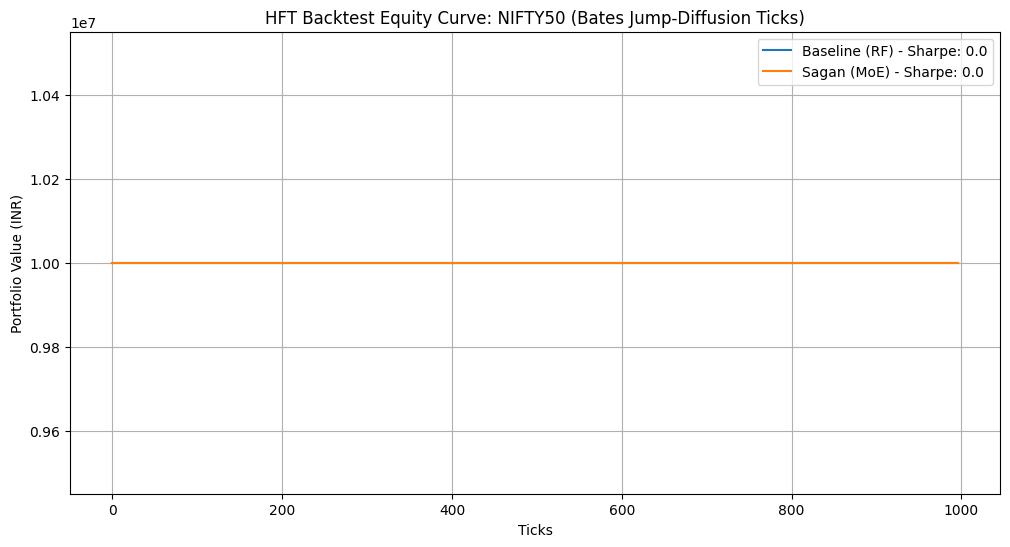

,total_return_pct,sharpe_ratio,max_drawdown,win_rate,fees_paid
Random Forest Baseline,0.0,0.0,0.0,0.0,0.0
Sagan MoE,0.0,0.0,0.0,0.0,0.0


In [5]:
# 5. Results & Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(res_baseline['portfolio_values'], label=f'Baseline (RF) - Sharpe: {metrics_rf["sharpe_ratio"]}')
plt.plot(res_sagan['portfolio_values'], label=f'Sagan (MoE) - Sharpe: {metrics_sagan["sharpe_ratio"]}')
plt.title('HFT Backtest Equity Curve: NIFTY50 (Bates Jump-Diffusion Ticks)')
plt.xlabel('Ticks')
plt.ylabel('Portfolio Value (INR)')
plt.legend()
plt.grid(True)
plt.show()

# Comparison Table
import pandas as pd
comp_df = pd.DataFrame([metrics_rf, metrics_sagan], index=['Random Forest Baseline', 'Sagan MoE'])
comp_df[['total_return_pct', 'sharpe_ratio', 'max_drawdown', 'win_rate', 'fees_paid']]
